In [1]:
import os
import warnings
os.chdir("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
df_listings = pd.read_csv('data/combined_csvs/listings_property_vals.csv')
print(len(df_listings))
before = len(df_listings)
df_listings = df_listings[df_listings["ttm_avg_rate"] <= 500]
print(before - len(df_listings))
df_listings = df_listings[~pd.isna(df_listings["gross_yield"])]
print(before - len(df_listings))

2882
164
321


In [3]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def create_city_level_clusters(
    df,
    target_cols,
    city_col="city",
    k_per_city=None,
    default_k=6,
    scaler=StandardScaler(),
    target_weight=0.5,
    use_median=True,  # Added flag to switch between median and mean
):
    """Groups data by city, applies K-Means clustering locally to each city using a city-specific k value,

    assigns a globally unique cluster ID, and calculates target medians (or means).
    """
    if k_per_city is None:
        k_per_city = {}

    print(
        f"Clustering by city using scaler={scaler.__class__.__name__}, target_weight={target_weight}..."
    )

    processed_cities = []

    # 1. Iterate through each city independently
    for city, city_df in df.groupby(city_col):
        n_samples = len(city_df)

        k_for_this_city = k_per_city.get(city, default_k)
        current_k = min(k_for_this_city, n_samples)

        if current_k < 2:
            city_df = city_df.copy()
            city_df["cluster_id"] = f"{city}_0"
            processed_cities.append(city_df)
            continue

        # 2. Extract and scale features (Spatial + Targets)
        # Note: Using target_cols[0] as in your provided snippet
        feature_cols = ["latitude", "longitude"] + [target_cols[0]]
        X = city_df[feature_cols].fillna(0).values

        local_scaler = clone(scaler)
        X_scaled = local_scaler.fit_transform(X)

        # 3. Apply the target weight
        X_scaled[:, 2:] *= target_weight

        # 4. Fit K-Means
        kmeans = KMeans(n_clusters=current_k, random_state=42, n_init=10)
        local_labels = kmeans.fit_predict(X_scaled)

        # 5. Create globally unique cluster IDs
        city_df = city_df.copy()
        city_df["cluster_id"] = [f"{city}_{label}" for label in local_labels]

        processed_cities.append(city_df)

    # 6. Combine all city dataframes back into one
    result_df = pd.concat(processed_cities)

    # 7. Aggregate by median (or mean)
    agg_type = "median" if use_median else "mean"
    print(f"Aggregating cluster {agg_type}s for: {target_cols}")

    if use_median:
        cluster_aggs = result_df.groupby("cluster_id")[target_cols].median()
        rename_dict = {col: f"cluster_median_{col}" for col in target_cols}
    else:
        cluster_aggs = result_df.groupby("cluster_id")[target_cols].mean()
        rename_dict = {col: f"cluster_avg_{col}" for col in target_cols}

    cluster_aggs = cluster_aggs.rename(columns=rename_dict)

    # 8. Merge aggregations back onto main dataframe
    result_df = result_df.merge(
        cluster_aggs, left_on="cluster_id", right_index=True, how="left"
    )

    return result_df

In [4]:
# Define the columns you want to average
targets = ['gross_yield', 'ttm_revenue', 'ttm_occupancy', 'property_val']

k_per_city = {
    'asheville': 10,
    'carolina beach': 8,
    'charlotte': 12,
    "durham": 8,
    'gatlinburg': 8,
    'myrtle beach': 8,
    'pigeon forge': 8,
    'raleigh': 10,
    'williamsburg': 10,
    'wilmington': 10,
}

# Run the function on your dataframe (assuming it's called df_listings)
df_clustered = create_city_level_clusters(
    df_listings, 
    target_cols=targets, 
    target_weight=0.15,
    k_per_city= k_per_city
)

Clustering by city using scaler=StandardScaler, target_weight=0.15...
Aggregating cluster medians for: ['gross_yield', 'ttm_revenue', 'ttm_occupancy', 'property_val']


In [5]:
# Save the dataframe to a CSV in your current working directory
df_clustered.to_csv('data/combined_csvs/listings_clustered.csv', index=False)

In [6]:
clustered_revenue = df_clustered.groupby("cluster_id")["ttm_revenue"].agg(
    count="count",
    avg="mean",
    median="median"
).reset_index()
clustered_gross_yield = df_clustered.groupby("cluster_id")["gross_yield"].agg(
    count="count",
    avg="mean",
    median="median"
).reset_index()
clustered_occupancy = df_clustered.groupby("cluster_id")["ttm_occupancy"].agg(
    count="count",
    avg="mean",
    median="median"
).reset_index()

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_80684/3683713796.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


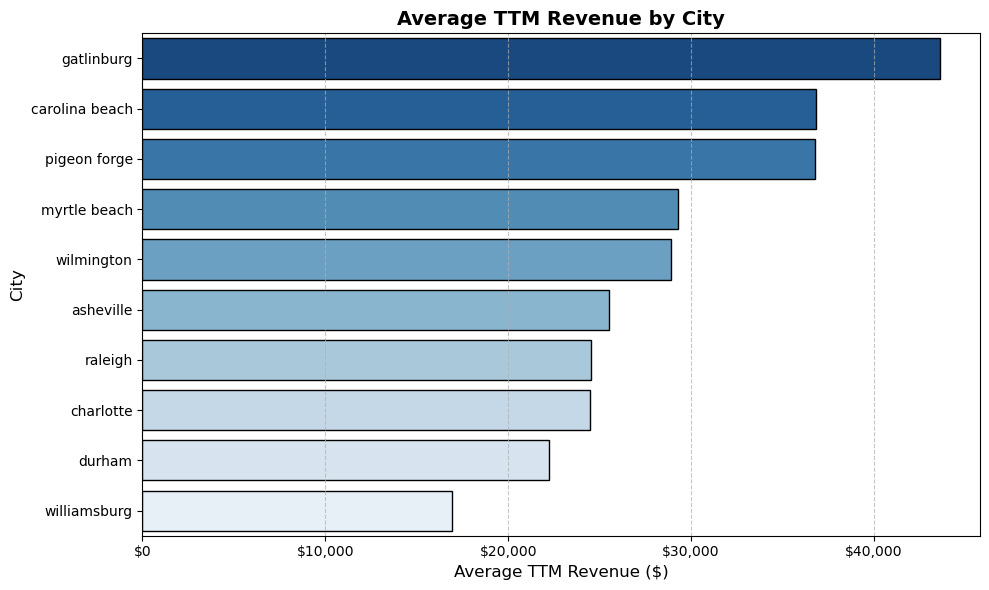

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate by city and sort by average TTM revenue descending
df_summary = (
    df_clustered.groupby("city")["ttm_revenue"]
    .agg(count="count", avg="mean", median="median")
    .reset_index()
    .sort_values(by="avg", ascending=False)
)

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_summary,
    y="city",
    x="avg",
    palette="Blues_r",
    edgecolor="black",
)

plt.title("Average TTM Revenue by City", fontsize=14, fontweight="bold")
plt.xlabel("Average TTM Revenue ($)", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Format x-axis as currency
ax.xaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_80684/2120168979.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


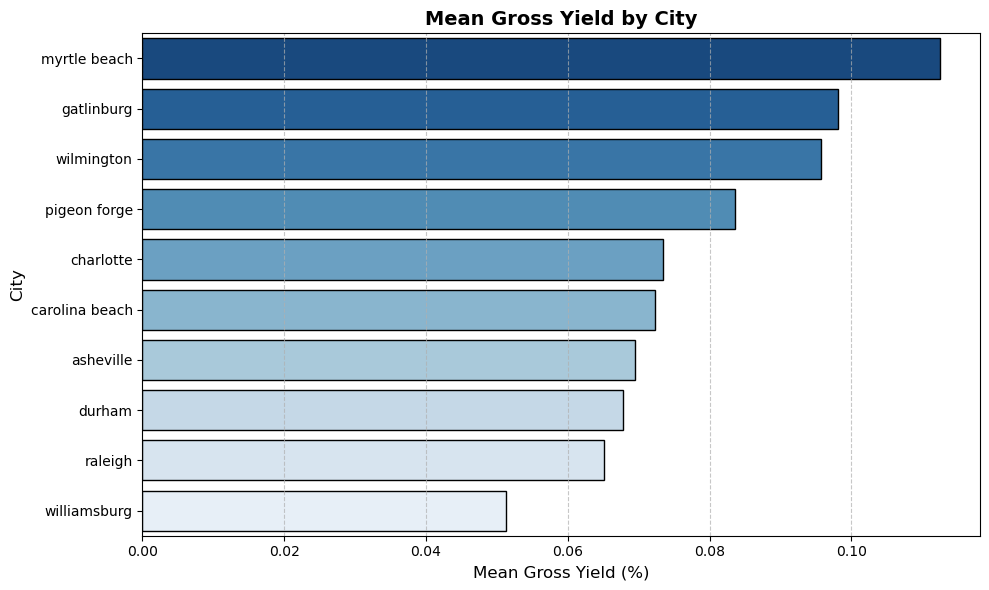

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate by city and sort by average TTM revenue descending
df_summary = (
    df_clustered.groupby("city")["gross_yield"]
    .agg(count="count", avg="mean", median="median")
    .reset_index()
    .sort_values(by="avg", ascending=False)
)

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_summary,
    y="city",
    x="avg",
    palette="Blues_r",
    edgecolor="black",
)

plt.title("Mean Gross Yield by City", fontsize=14, fontweight="bold")
plt.xlabel("Mean Gross Yield (%)", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import scipy.stats as stats

# Define target cities
target_cities = ["myrtle beach", "gatlinburg", "wilmington", "pigeon forge"]

# Create binary indicator column
df_clustered["is_target"] = df_clustered["city"].isin(target_cities)

group_target = df_clustered[df_clustered["is_target"]]["gross_yield"]
group_rest = df_clustered[~df_clustered["is_target"]]["gross_yield"]

# 1. Welch's t-test (unequal variances assumed, one-tailed)
t_stat, p_val_two = stats.ttest_ind(
    group_target, group_rest, equal_var=False, nan_policy="omit"
)

# Convert 2-tailed p-value to 1-tailed (testing if target > rest)
p_val_one = p_val_two / 2 if t_stat > 0 else 1.0 - (p_val_two / 2)

print(
    f"Welch's t-stat: {t_stat:.3f}, One-tailed p-value: {p_val_one:.4e}"
)

# 2. Mann-Whitney U Test (Non-parametric fallback if data is non-normal)
u_stat, p_val_u = stats.mannwhitneyu(
    group_target, group_rest, alternative="greater"
)
print(f"Mann-Whitney U: {u_stat:.3f}, One-tailed p-value: {p_val_u:.4e}")

Welch's t-stat: 11.822, One-tailed p-value: 2.4864e-31
Mann-Whitney U: 980902.000, One-tailed p-value: 3.2188e-25


In [12]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Clean data: drop NaNs and standardize string matching
df_clean = df_clustered.dropna(subset=["gross_yield", "city"]).copy()
df_clean["city"] = df_clean["city"].astype(str).str.strip()

# Target cities formatted for robust matching
target_cities_raw = ["Myrtle Beach", "Gatlinburg", "Wilmington"]
target_cities_lower = [c.lower() for c in target_cities_raw]

# Check which target cities actually exist in the dataset
df_clean["city_lower"] = df_clean["city"].str.lower()
available_targets = df_clean[df_clean["city_lower"].isin(target_cities_lower)]["city"].unique()

print(f"Matched target cities in dataset: {list(available_targets)}")

if len(available_targets) == 0:
    print("\nError: None of your target cities were found in the dataset.")
    print("Available cities in your data are:")
    print(df_clean["city"].unique())
else:
    # Group data by city
    all_cities = df_clean["city"].unique()
    groups = [group["gross_yield"].values for _, group in df_clean.groupby("city")]

    # 2. Step 1: Overall Kruskal-Wallis Test
    h_stat, p_val_kw = stats.kruskal(*groups)
    print(f"\n=== Kruskal-Wallis Test ===")
    print(f"H-statistic: {h_stat:.4f}")
    print(f"p-value: {p_val_kw:.4e}\n")

    if p_val_kw < 0.05:
        print("Statistically significant overall difference found. Running post-hoc Mann-Whitney U tests...\n")
        
        results = []
        
        # 3. Step 2: Post-hoc Pairwise Mann-Whitney U for target cities
        for target in available_targets:
            target_data = df_clean[df_clean["city"] == target]["gross_yield"]
            
            for other_city in all_cities:
                if target == other_city:
                    continue
                
                other_data = df_clean[df_clean["city"] == other_city]["gross_yield"]
                
                # Ensure both groups have enough data points
                if len(target_data) > 0 and len(other_data) > 0:
                    u_stat, p_val = stats.mannwhitneyu(
                        target_data, other_data, alternative="two-sided"
                    )
                    
                    target_med = target_data.median()
                    other_med = other_data.median()
                    
                    results.append({
                        "target_city": target,
                        "compared_to": other_city,
                        "target_median": target_med,
                        "other_median": other_med,
                        "median_diff": target_med - other_med,
                        "u_stat": u_stat,
                        "p_raw": p_val
                    })

        res_df = pd.DataFrame(results)

        if not res_df.empty:
            # 4. Step 3: Bonferroni Correction
            num_comparisons = len(res_df)
            res_df["p_adj"] = np.minimum(res_df["p_raw"] * num_comparisons, 1.0)
            res_df["reject_null"] = res_df["p_adj"] < 0.05

            res_df = res_df.sort_values("p_adj")

            # --- Output Significant Comparisons ---
            print("=========================================================================")
            print("=== STATISTICALLY SIGNIFICANT COMPARISONS (p_adj < 0.05) ===")
            print("=========================================================================")
            sig_df = res_df[res_df["reject_null"] == True]
            if not sig_df.empty:
                print(sig_df[["target_city", "compared_to", "target_median", "other_median", "median_diff", "p_adj"]].to_string(index=False))
            else:
                print("No pairwise comparisons reached statistical significance after Bonferroni correction.")

            # --- Output Non-Significant Comparisons ---
            print("\n=========================================================================")
            print("=== NON-SIGNIFICANT COMPARISONS (p_adj >= 0.05) ===")
            print("=========================================================================")
            non_sig_df = res_df[res_df["reject_null"] == False]
            if not non_sig_df.empty:
                print(non_sig_df[["target_city", "compared_to", "target_median", "other_median", "median_diff", "p_adj"]].to_string(index=False))
            else:
                print("All pairwise comparisons were statistically significant.")

        else:
            print("No valid pairwise comparisons could be generated.")
    else:
        print("Kruskal-Wallis test was not significant (p >= 0.05). No evidence of overall yield differences between cities.")

Matched target cities in dataset: ['gatlinburg', 'myrtle beach', 'wilmington']

=== Kruskal-Wallis Test ===
H-statistic: 162.6777
p-value: 2.0618e-30

Statistically significant overall difference found. Running post-hoc Mann-Whitney U tests...

=== STATISTICALLY SIGNIFICANT COMPARISONS (p_adj < 0.05) ===
 target_city    compared_to  target_median  other_median  median_diff        p_adj
  wilmington   williamsburg       0.084686      0.035563     0.049123 2.705961e-18
myrtle beach   williamsburg       0.091272      0.035563     0.055709 2.937305e-18
  gatlinburg   williamsburg       0.083866      0.035563     0.048303 8.543232e-16
myrtle beach      asheville       0.091272      0.056632     0.034640 6.700701e-08
myrtle beach        raleigh       0.091272      0.061522     0.029750 7.134612e-08
  wilmington        raleigh       0.084686      0.061522     0.023164 3.935155e-07
myrtle beach         durham       0.091272      0.062585     0.028687 6.283311e-07
  wilmington      asheville   

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/1219768879.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


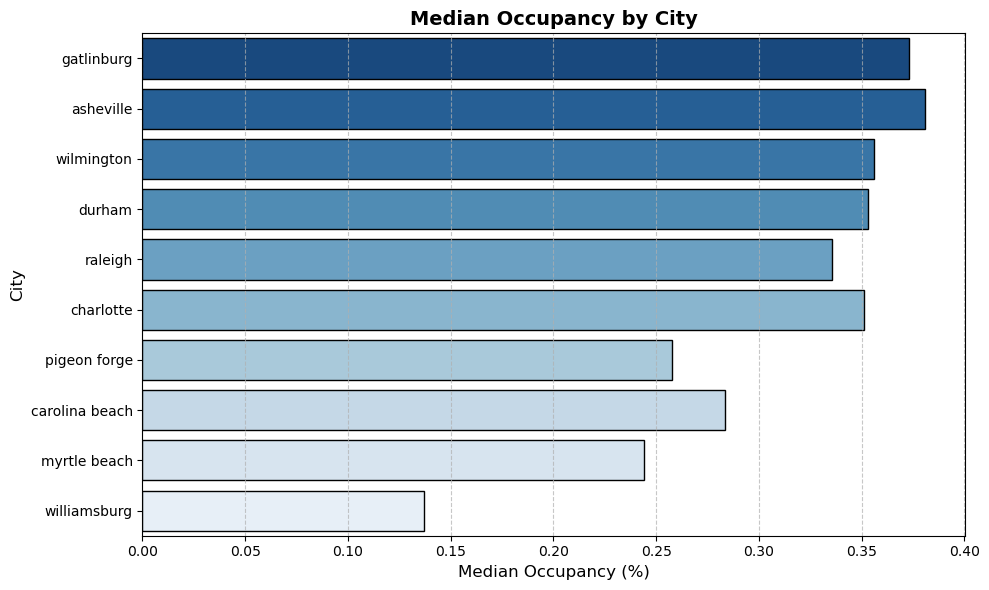

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate by city and sort by average TTM revenue descending
df_summary = (
    df_clustered.groupby("city")["ttm_occupancy"]
    .agg(count="count", avg="mean", median="median")
    .reset_index()
    .sort_values(by="avg", ascending=False)
)

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_summary,
    y="city",
    x="median",
    palette="Blues_r",
    edgecolor="black",
)

plt.title("Median Occupancy by City", fontsize=14, fontweight="bold")
plt.xlabel("Median Occupancy (%)", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


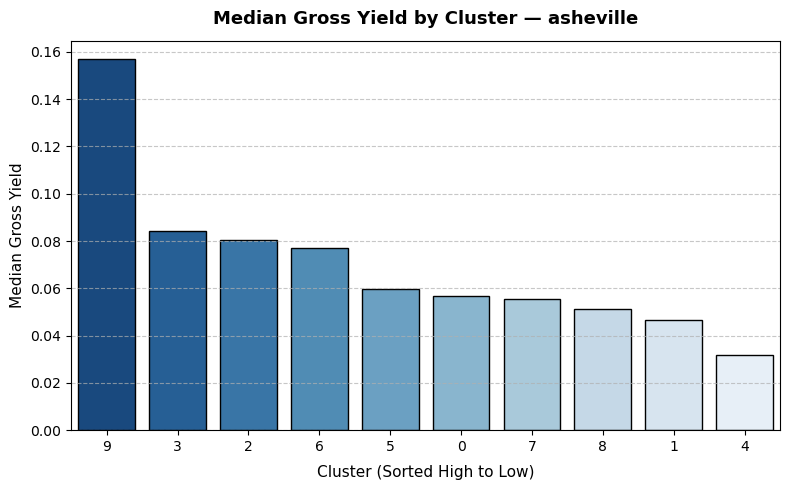

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


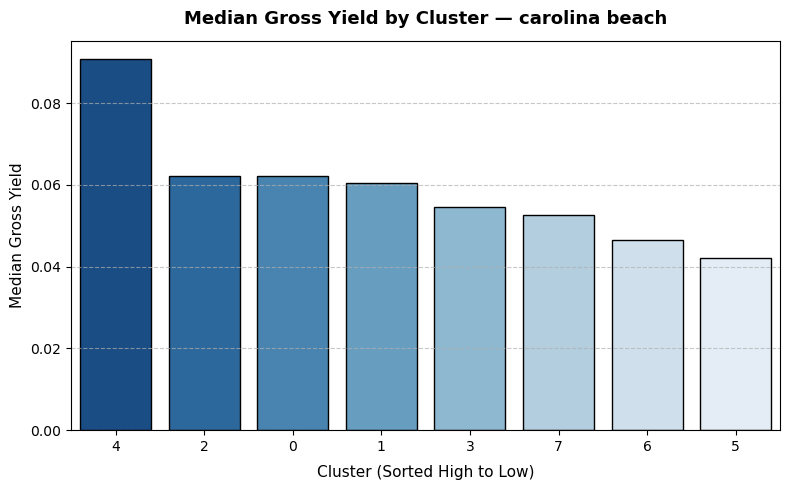

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


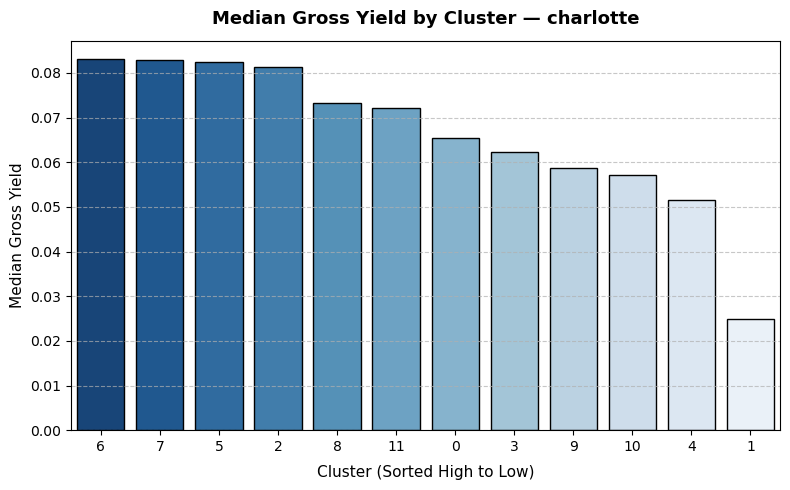

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


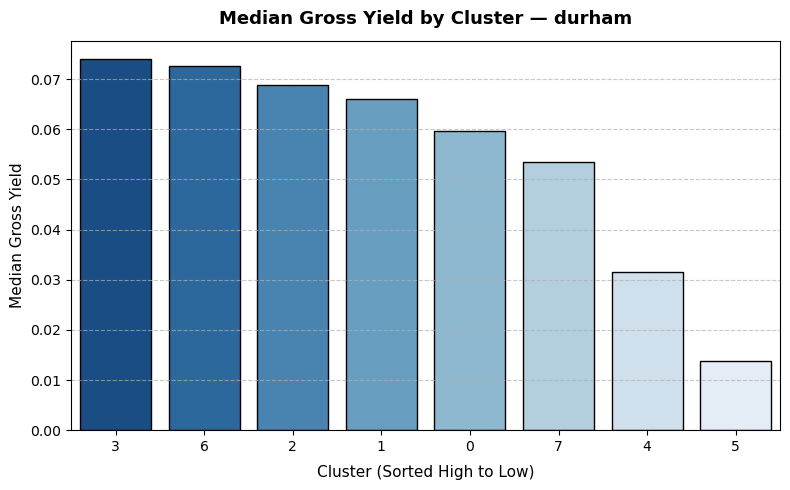

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


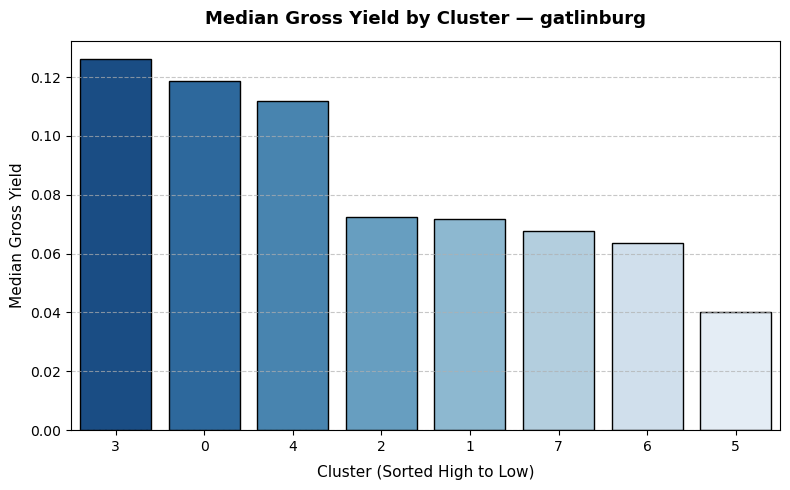

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


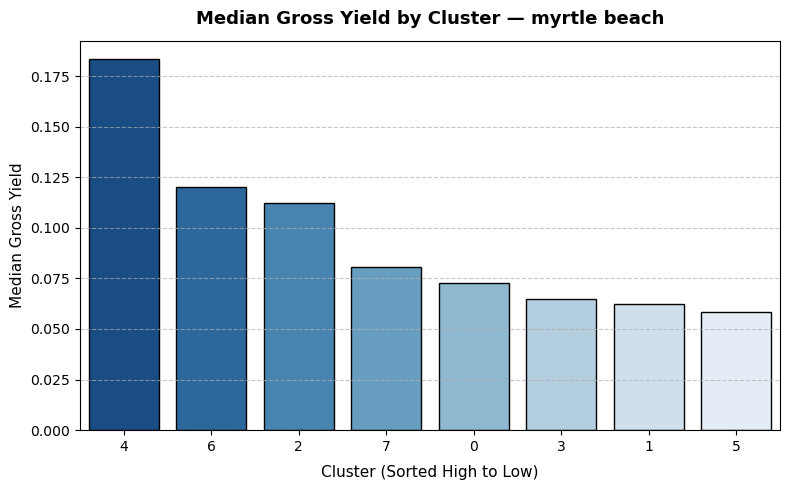

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


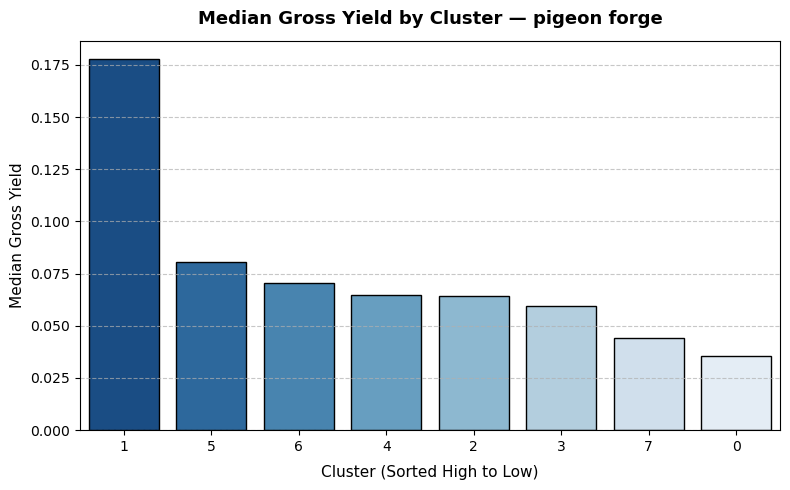

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


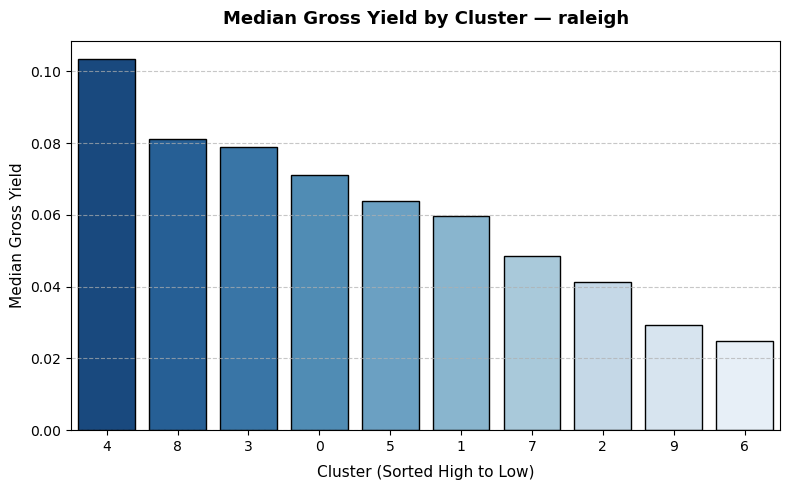

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


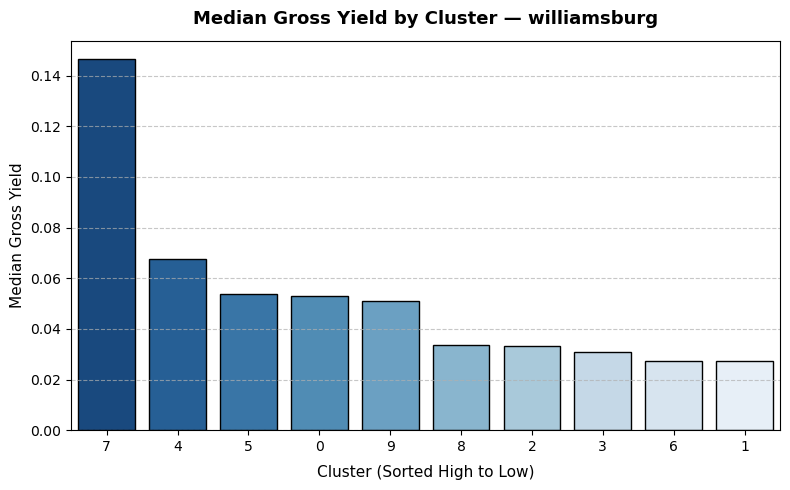

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_75180/3703045146.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


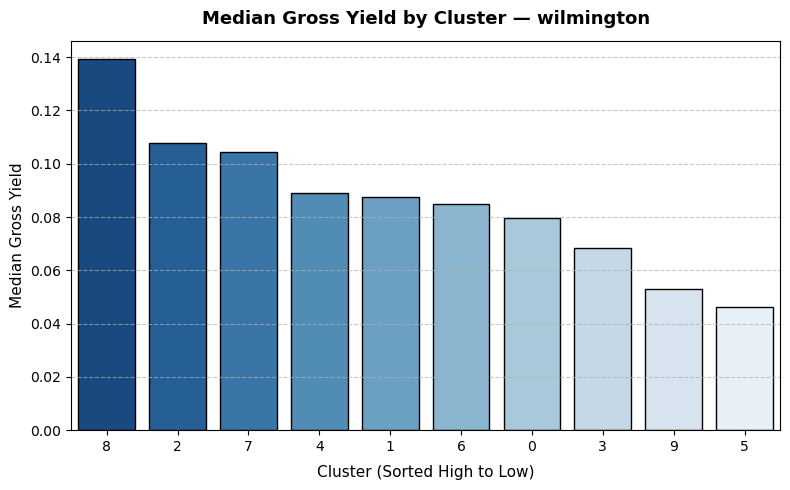

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate by city and cluster_id
df_summary = (
    df_clustered.groupby(["city", "cluster_id"])["gross_yield"]
    .agg(count="count", avg="mean", median="median")
    .reset_index()
)

# 2. Separate plot for each city with sorted x-axis showing only the number after '_'
for city_name, city_df in df_summary.groupby("city"):
    plt.figure(figsize=(8, 5))

    # Sort clusters descending by avg
    sorted_df = city_df.sort_values(by="median", ascending=False).copy()

    # Split cluster_id by '_' and extract the value after the underscore
    sorted_df["cluster_label"] = (
        sorted_df["cluster_id"].astype(str).apply(lambda x: x.split("_")[-1])
    )

    ax = sns.barplot(
        data=sorted_df,
        x="cluster_label",
        y="median",
        palette="Blues_r",
        edgecolor="black",
    )

    # Labels and formatting
    plt.title(
        f"Median Gross Yield by Cluster — {city_name}",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    plt.xlabel("Cluster (Sorted High to Low)", fontsize=11, labelpad=8)
    plt.ylabel("Median Gross Yield", fontsize=11)

    plt.xticks(rotation=0, fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()